# CornGuard 01: Training YOLOv8 (deteksi Bulai jagung)

Notebook ini **hanya untuk training**. Evaluasi dan ekspor ada di notebook `02_Evaluasi_Ekspor_YOLO_Bulai.ipynb`.

**Cara pakai**
- Wajib runtime **GPU** (Runtime > Change runtime type > T4 GPU), lalu jalankan dari atas ke bawah.
- Training memakan waktu beberapa jam. Hasilnya (`best.pt`, `last.pt`, grafik) tersimpan otomatis di Drive (`DRIVE_OUT`).
- Kalau Colab terputus saat training: jalankan ulang bagian 1 sampai 3, **lewati sel training**, lalu pakai sel **resume**.
- **Jangan jalankan notebook ini lagi kalau hanya ingin evaluasi atau ekspor.** Nama run yang sama (`exist_ok=True`) akan menimpa hasil lama.

## 1. Setup
Cek GPU, install Ultralytics, mount Google Drive.

In [ ]:
!nvidia-smi
!pip install -q ultralytics

from google.colab import drive
drive.mount('/content/drive')

import ultralytics
ultralytics.checks()

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.4/112.6 GB disk)


## 2. Konfigurasi
Semua pengaturan dikumpulkan di satu sel ini, supaya gampang diubah.

In [ ]:
ZIP_PATH    = "/content/drive/MyDrive/CornGuard/BULAI JAGUNG.v7i.yolov8.zip"
DATASET_DIR = "/content/dataset"
DRIVE_OUT   = "/content/drive/MyDrive/CornGuard/training_bulai"   # folder hasil training di Drive

SEED            = 42
BULAI_CLASS_ID  = "0"    # index kelas Bulai di data.yaml asli (lihat Preprocessing notebook)
BG_RATIO        = 0      # rasio foto background (non-Bulai) yang dipertahankan, 0 = dibuang semua

MODEL_NAME = "yolov8s.pt"
EPOCHS     = 150         # batas atas; early stopping (PATIENCE) bisa menghentikan lebih awal
PATIENCE   = 50
IMGSZ      = 960
BATCH      = 16          # kalau muncul CUDA out of memory, turunkan ke 8
RUN_NAME   = "bulai_yolov8s_960"   # ganti nama kalau mau run baru, supaya hasil lama tidak tertimpa

## 3. Persiapan dataset
**Unzip** dataset dari Drive ke `/content/dataset`.

In [ ]:
import zipfile
import shutil
import os

if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(DATASET_DIR)

for split in ["train", "valid", "test"]:
    print(f"{split}: {len(os.listdir(f'{DATASET_DIR}/{split}/images'))} gambar (asli, 3 kelas)")

train: 3217 gambar (asli, 3 kelas)
valid: 322 gambar (asli, 3 kelas)
test: 169 gambar (asli, 3 kelas)


**Filter:** hanya kelas Bulai yang disisakan, lalu foto tanpa Bulai dibuang.

In [ ]:
import random
random.seed(SEED)

summary = {}
for split in ["train", "valid", "test"]:
    img_dir = f"{DATASET_DIR}/{split}/images"
    lbl_dir = f"{DATASET_DIR}/{split}/labels"
    kept, bg_kept, removed, boxes = 0, 0, 0, 0
    empty_files = []

    for fname in sorted(os.listdir(lbl_dir)):
        lbl_path = os.path.join(lbl_dir, fname)
        with open(lbl_path) as f:
            lines = [l for l in f.read().splitlines() if l.strip()]

        bulai_lines = [l for l in lines if l.split()[0] == BULAI_CLASS_ID]
        with open(lbl_path, "w") as f:
            f.write("\n".join(bulai_lines) + ("\n" if bulai_lines else ""))

        if bulai_lines:
            kept += 1
            boxes += len(bulai_lines)
        else:
            empty_files.append(fname)

    n_bg = int(kept * BG_RATIO)
    keep_bg = set(random.sample(empty_files, min(n_bg, len(empty_files))))

    for fname in empty_files:
        if fname in keep_bg:
            bg_kept += 1
            continue
        base = os.path.splitext(fname)[0]
        for ext in [".jpg", ".jpeg", ".png"]:
            p = os.path.join(img_dir, base + ext)
            if os.path.exists(p):
                os.remove(p)
                break
        os.remove(os.path.join(lbl_dir, fname))
        removed += 1

    summary[split] = (kept, bg_kept, removed, boxes)
    print(f"{split}: foto bulai={kept}, background={bg_kept}, dibuang={removed}, box bulai={boxes}")

train: foto bulai=1190, background=0, dibuang=2027, box bulai=24145
valid: foto bulai=107, background=0, dibuang=215, box bulai=2300
test: foto bulai=68, background=0, dibuang=101, box bulai=1220


**Verifikasi:** jumlah gambar dan label cocok, dan yang tersisa hanya class-id 0.

In [ ]:
for split in ["train", "valid", "test"]:
    img_dir = f"{DATASET_DIR}/{split}/images"
    lbl_dir = f"{DATASET_DIR}/{split}/labels"
    imgs = {os.path.splitext(f)[0] for f in os.listdir(img_dir)}
    lbls = {os.path.splitext(f)[0] for f in os.listdir(lbl_dir)}
    ids = set()
    for f in os.listdir(lbl_dir):
        for line in open(os.path.join(lbl_dir, f)):
            if line.strip():
                ids.add(line.split()[0])
    status = "OK" if imgs == lbls and ids <= {"0"} else "!! CEK ULANG"
    print(f"{split}: images={len(imgs)}, labels={len(lbls)}, class-id={ids} -> {status}")

train: images=1190, labels=1190, class-id={'0'} -> OK
valid: images=107, labels=107, class-id={'0'} -> OK
test: images=68, labels=68, class-id={'0'} -> OK


**data.yaml** ditulis ulang pakai path absolut, supaya tidak muncul error "dataset not found".

In [ ]:
import yaml

data_yaml = {
    "path": DATASET_DIR,
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 1,
    "names": ["Bulai"],
}
YAML_PATH = f"{DATASET_DIR}/data.yaml"
with open(YAML_PATH, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(open(YAML_PATH).read())

path: /content/dataset
train: train/images
val: valid/images
test: test/images
nc: 1
names:
- Bulai



**Cek visual:** contoh gambar beserta kotak labelnya, untuk memastikan label menempel di gejala bulai.

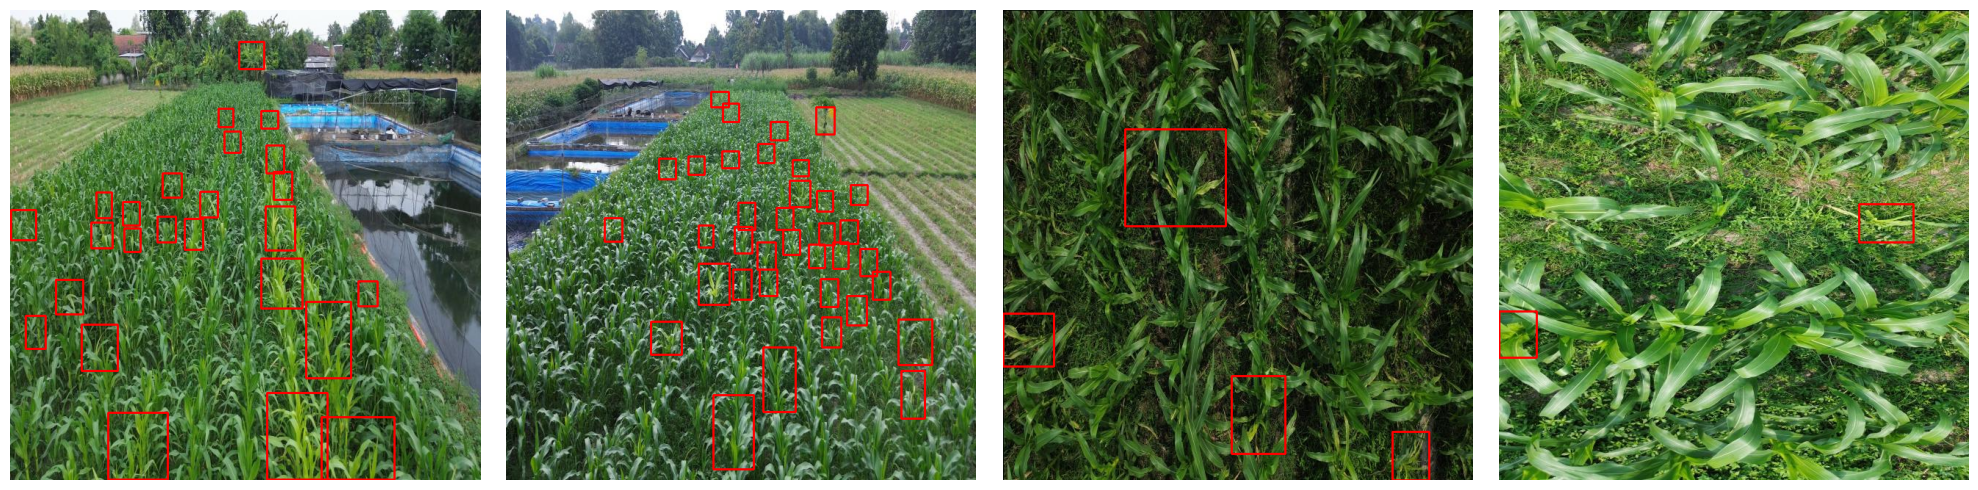

In [ ]:
import cv2, glob
import matplotlib.pyplot as plt

samples = random.sample(glob.glob(f"{DATASET_DIR}/train/images/*"), 4)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, img_path in zip(axes, samples):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lbl_path = img_path.replace("/images/", "/labels/").rsplit(".", 1)[0] + ".txt"
    for line in open(lbl_path):
        _, xc, yc, bw, bh = map(float, line.split())
        x1, y1 = int((xc - bw/2) * w), int((yc - bh/2) * h)
        x2, y2 = int((xc + bw/2) * w), int((yc + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
    ax.imshow(img); ax.axis("off")
plt.tight_layout(); plt.show()

## 4. Training
Hasil disimpan langsung ke Drive (`DRIVE_OUT`). **Lewati bagian ini kalau hanya ingin evaluasi.**

In [ ]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU tidak terdeteksi. Di Colab: Runtime > Change runtime type > pilih GPU, "
        "lalu Reconnect, baru jalankan ulang sel ini. Training di CPU bisa makan belasan jam per epoch."
    )
print("GPU terdeteksi:", torch.cuda.get_device_name(0))

GPU terdeteksi: Tesla T4


In [ ]:
from ultralytics import YOLO

model = YOLO(MODEL_NAME)

results = model.train(
    data=YAML_PATH,
    epochs=EPOCHS,
    patience=PATIENCE,
    imgsz=IMGSZ,
    batch=BATCH,
    optimizer="auto",
    flipud=0.5,          # banyak foto drone, orientasi daun bebas
    seed=SEED,
    device=0,            # paksa pakai GPU index 0, biar langsung error kalau GPU hilang (bukan diam-diam jatuh ke CPU)
    project=DRIVE_OUT,
    name=RUN_NAME,
    exist_ok=True,
    plots=True,
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bulai_yolov8s_960, nbs=64, nms=None, opset=None, optimize=Fals

**Resume (opsional):** jalankan hanya kalau Colab terputus saat training. Ubah `RESUME` jadi `True`.

In [ ]:
RESUME = False

if RESUME:
    from ultralytics import YOLO
    model = YOLO(f"{DRIVE_OUT}/{RUN_NAME}/weights/last.pt")
    model.train(resume=True)

## Selesai
Training selesai kalau `best.pt` sudah muncul di `DRIVE_OUT/RUN_NAME/weights/`. Lanjut ke notebook **02_Evaluasi_Ekspor_YOLO_Bulai.ipynb**.

Pastikan `RUN_NAME`, `IMGSZ`, dan `DRIVE_OUT` di notebook 02 **sama persis** dengan yang dipakai di sini.